In [ ]:
# Import all required libraries
import os
import shutil
import glob
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import kagglehub

import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

print("All libraries imported successfully!")
print(f"PyTorch Version: {torch.__version__}")

All libraries imported successfully!
PyTorch Version: 2.11.0+cu128


## Step 1: Download & Locate Dataset
We download the "Forest Fire, Smoke, and Non-Fire" dataset using `kagglehub` and examine its directory structure.

In [ ]:
# Download latest version of dataset
raw_dataset_path = kagglehub.dataset_download("amerzishminha/forest-fire-smoke-and-non-fire-image-dataset")

print("Path to downloaded dataset files:", raw_dataset_path)

# List sub-folders/files in the downloaded path
dataset_dir = Path(raw_dataset_path)

# If dataset contains a subfolder, traverse down to find image class folders
subfolders = [f for f in dataset_dir.glob('*') if f.is_dir()]
print("\nDetected directories inside dataset path:")
for folder in subfolders:
    print(f" - {folder.name}")

100%|██████████| 6.43G/6.43G [05:10<00:00, 22.2MB/s]

Extracting files...


Path to downloaded dataset files: /root/.cache/kagglehub/datasets/amerzishminha/forest-fire-smoke-and-non-fire-image-dataset/versions/3

Detected directories inside dataset path:
 - FOREST_FIRE_SMOKE_AND_NON_FIRE_DATASET


## Step 2: Data Cleaning & Integrity Verification
Before splitting or modeling, we verify that every image can be read properly and identify any corrupted or invalid files.

In [ ]:
# Supported image extensions
VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp')

valid_image_paths = []
corrupted_files = []

# Scan through all directories and check image files
for root, _, files in os.walk(raw_dataset_path):
    for file in files:
        if file.lower().endswith(VALID_EXTENSIONS):
            full_path = os.path.join(root, file)
            try:
                # Test opening the image to detect corruption
                with Image.open(full_path) as img:
                    img.verify()  # Verify image header
                valid_image_paths.append(full_path)
            except Exception as e:
                print(f"Corrupted image detected & excluded: {full_path} | Error: {e}")
                corrupted_files.append(full_path)

print("\n--- Data Cleaning Summary ---")
print(f"Total Valid Images Found: {len(valid_image_paths)}")
print(f"Total Corrupted Files Removed: {len(corrupted_files)}")


--- Data Cleaning Summary ---
Total Valid Images Found: 41152
Total Corrupted Files Removed: 0


## Step 3: Exploratory Data Analysis (EDA) & Visualization
Here we inspect the class balance (number of images per class) and display sample images from each category.

--- Class Distribution Summary ---
 • Fire: 14,298 images
 • Smoke: 12,554 images
 • Non fire: 14,300 images


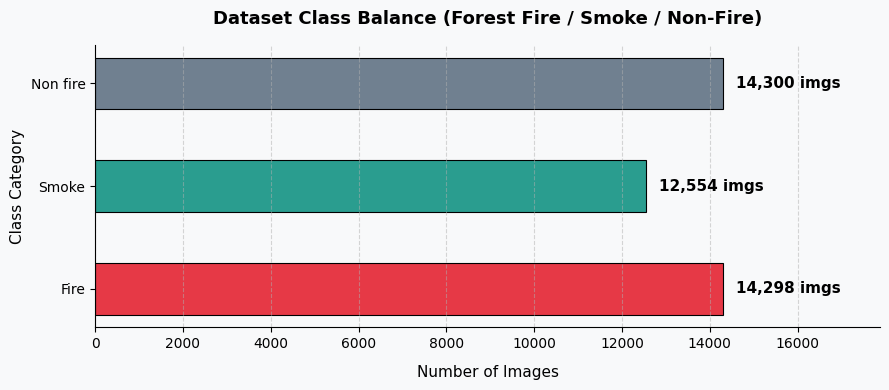

In [ ]:
from collections import defaultdict

# Group valid images by unique class name
class_counts = defaultdict(int)
unique_class_paths = {}

for file_path in dataset_dir.rglob('*'):
    if file_path.is_file() and file_path.suffix.lower() in VALID_EXTENSIONS:
        parent_name = file_path.parent.name.capitalize()
        class_counts[parent_name] += 1
        if parent_name not in unique_class_paths:
            unique_class_paths[parent_name] = file_path.parent

print("--- Class Distribution Summary ---")
for cname, count in class_counts.items():
    print(f" • {cname}: {count:,} images")

# Plotting Horizontal Bar Chart
plt.figure(figsize=(9, 4), facecolor='#f8f9fa')
categories = list(class_counts.keys())
values = list(class_counts.values())

bar_colors = ['#e63946', '#2a9d8f', '#708090']

bars = plt.barh(categories, values, color=bar_colors[:len(categories)], height=0.5, edgecolor='black', linewidth=0.8)

# Add text labels on the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width + (max(values) * 0.02), bar.get_y() + bar.get_height()/2,
             f'{width:,} imgs', va='center', ha='left', fontsize=11, fontweight='bold')

plt.title("Dataset Class Balance (Forest Fire / Smoke / Non-Fire)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Number of Images", fontsize=11, labelpad=10)
plt.ylabel("Class Category", fontsize=11)
plt.xlim(0, max(values) * 1.25)

plt.gca().set_facecolor('#f8f9fa')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

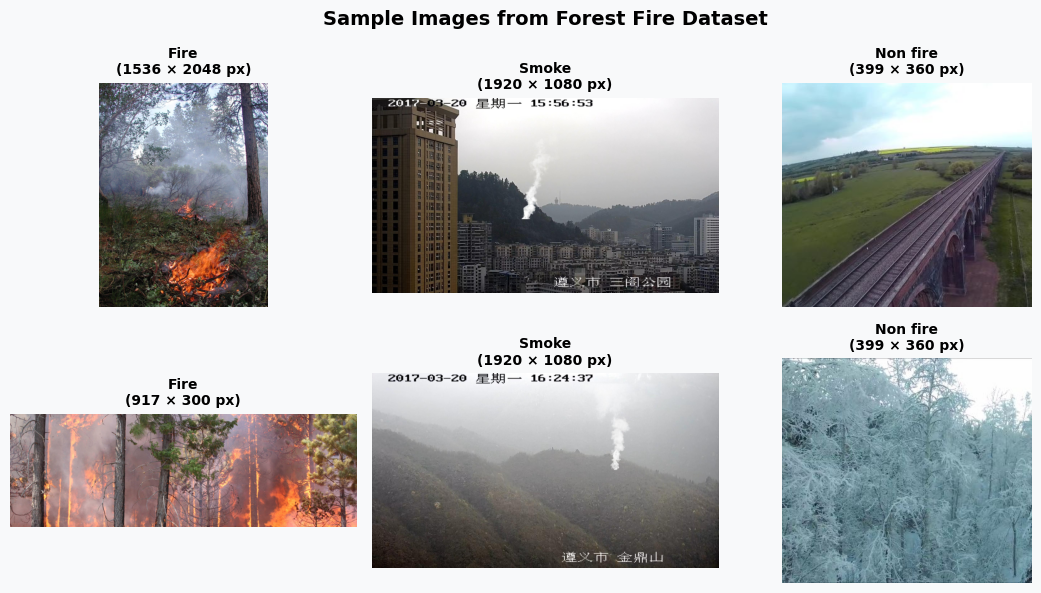

In [ ]:
# Visualizing 2 Sample Images per Class in a strict 3-Column Grid
classes = list(unique_class_paths.keys())
num_classes = len(classes)

fig, axes = plt.subplots(2, num_classes, figsize=(11, 6), facecolor='#f8f9fa')

for col_idx, cname in enumerate(classes):
    cfolder = unique_class_paths[cname]
    sample_images = [f for f in cfolder.glob('*.*') if f.suffix.lower() in VALID_EXTENSIONS][:2]

    for row_idx in range(2):
        ax = axes[row_idx, col_idx]

        if row_idx < len(sample_images):
            img_path = sample_images[row_idx]
            img = Image.open(img_path)

            ax.imshow(img)
            ax.set_title(f"{cname}\n({img.size[0]} × {img.size[1]} px)",
                         fontsize=10, fontweight='bold', pad=6)

        ax.axis('off')

plt.suptitle("Sample Images from Forest Fire Dataset", fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## Step 4: Dataset Splitting (70% Train, 15% Validation, 15% Test)
We restructure the dataset into organized directories (`train`, `val`, `test`) to maintain clean separation for model training.

In [ ]:
import shutil
from sklearn.model_selection import train_test_split
from pathlib import Path

PROCESSED_DIR = Path("./data/processed")

# Split valid images into Train (70%), Val (15%), Test (15%)
train_paths, temp_paths = train_test_split(valid_image_paths, test_size=0.30, random_state=42)
val_paths, test_paths = train_test_split(temp_paths, test_size=0.50, random_state=42)

def copy_split(paths, split_name):
    for p in paths:
        class_name = Path(p).parent.name
        dest = PROCESSED_DIR / split_name / class_name
        dest.mkdir(parents=True, exist_ok=True)
        shutil.copy(p, dest / Path(p).name)

copy_split(train_paths, 'train')
copy_split(val_paths, 'val')
copy_split(test_paths, 'test')

print(f"Done! Split counts -> Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")

Done! Split counts -> Train: 28806 | Val: 6173 | Test: 6173


## Step 5: Preprocessing & Data Augmentation Pipeline
We define image transformations:
* **Training Set:** Resizing, Random Horizontal Flips, Random Rotation, Color Jitter, and Normalization (Augmentation).
* **Validation/Test Set:** Resizing and Normalization only (no spatial distortion).

In [ ]:
# Define Image Dimensions & Batch Size
from torchvision import transforms
from torchvision import datasets
from torch.utils.data import DataLoader
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# Training Augmentation & Preprocessing Pipeline
train_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Validation & Test Preprocessing Pipeline (No Random Augmentations)
eval_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create PyTorch ImageFolder Datasets
train_dataset = datasets.ImageFolder(
    root=str(PROCESSED_DIR / "train"),
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    root=str(PROCESSED_DIR / "val"),
    transform=eval_transforms
)

test_dataset = datasets.ImageFolder(
    root=str(PROCESSED_DIR / "test"),
    transform=eval_transforms
)

# Build DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders prepared successfully!")
print(f"Total Batches in Train Loader: {len(train_loader)}")
print(f"Total Batches in Val Loader:   {len(val_loader)}")
print(f"Total Batches in Test Loader:  {len(test_loader)}")

DataLoaders prepared successfully!
Total Batches in Train Loader: 809
Total Batches in Val Loader:   189
Total Batches in Test Loader:  189


## Step 6: Verify PyTorch DataLoaders & Augmented Batch
Finally, we sample a batch from `train_loader` and visualize normalized augmented outputs to confirm readiness for model training.

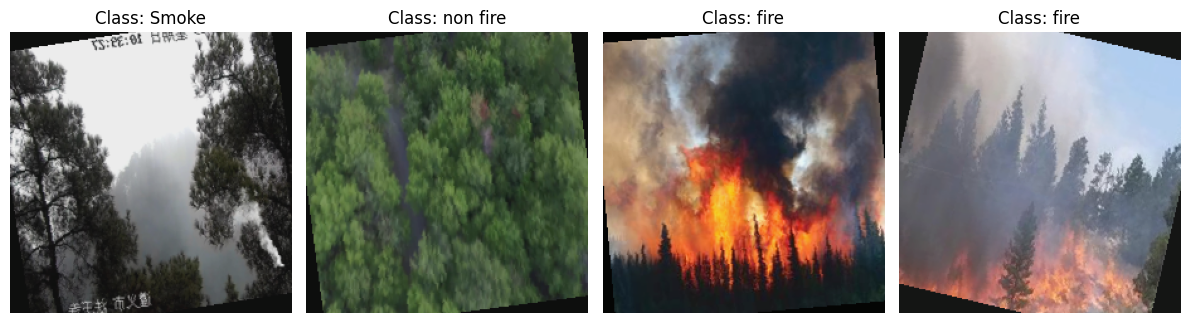

In [ ]:
# Helper function to un-normalize and display image tensor
def imshow_tensor(tensor_img, title=None):
    img = tensor_img.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean  # Un-normalize
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis('off')

# Fetch 1 batch from train_loader
images, labels = next(iter(train_loader))
class_names = train_dataset.classes

# Display first 4 samples of the batch
plt.figure(figsize=(12, 4))
for i in range(min(4, len(images))):
    plt.subplot(1, 4, i + 1)
    imshow_tensor(images[i], title=f"Class: {class_names[labels[i]]}")
plt.tight_layout()
plt.show()

# Step 7: Model 1 - Baseline CNN

In [ ]:
import torch.nn as nn
import torch.optim as optim
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# step 8: Define the baseline CNN architecture.

In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(BaselineCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 28 * 28, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

In [ ]:
model = BaselineCNN(num_classes=3).to(device)
print(model)

BaselineCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=50176, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
)


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# step 9: Training loop function

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        start_time = time.time()

        # Training phase
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # Validation phase
        model.eval()
        val_running_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        val_loss = val_running_loss / val_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        elapsed = time.time() - start_time
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | Time: {elapsed:.1f}s")

    return history

In [ ]:
history = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=10)

Epoch 1/10 | Train Loss: 0.2758 Acc: 0.9060 | Val Loss: 0.1615 Acc: 0.9426 | Time: 501.2s
Epoch 2/10 | Train Loss: 0.1892 Acc: 0.9411 | Val Loss: 0.1376 Acc: 0.9517 | Time: 488.1s
Epoch 3/10 | Train Loss: 0.1632 Acc: 0.9475 | Val Loss: 0.1338 Acc: 0.9540 | Time: 480.0s
Epoch 4/10 | Train Loss: 0.1452 Acc: 0.9529 | Val Loss: 0.1192 Acc: 0.9597 | Time: 481.4s
Epoch 5/10 | Train Loss: 0.1378 Acc: 0.9561 | Val Loss: 0.1207 Acc: 0.9603 | Time: 482.2s
Epoch 6/10 | Train Loss: 0.1206 Acc: 0.9617 | Val Loss: 0.1019 Acc: 0.9666 | Time: 483.0s
Epoch 7/10 | Train Loss: 0.1186 Acc: 0.9626 | Val Loss: 0.1043 Acc: 0.9685 | Time: 482.5s
Epoch 8/10 | Train Loss: 0.1143 Acc: 0.9623 | Val Loss: 0.1125 Acc: 0.9671 | Time: 482.5s
Epoch 9/10 | Train Loss: 0.1091 Acc: 0.9652 | Val Loss: 0.0882 Acc: 0.9733 | Time: 483.8s
Epoch 10/10 | Train Loss: 0.1018 Acc: 0.9689 | Val Loss: 0.0970 Acc: 0.9724 | Time: 489.3s


# step 10: plot and save the accuracy/loss curves

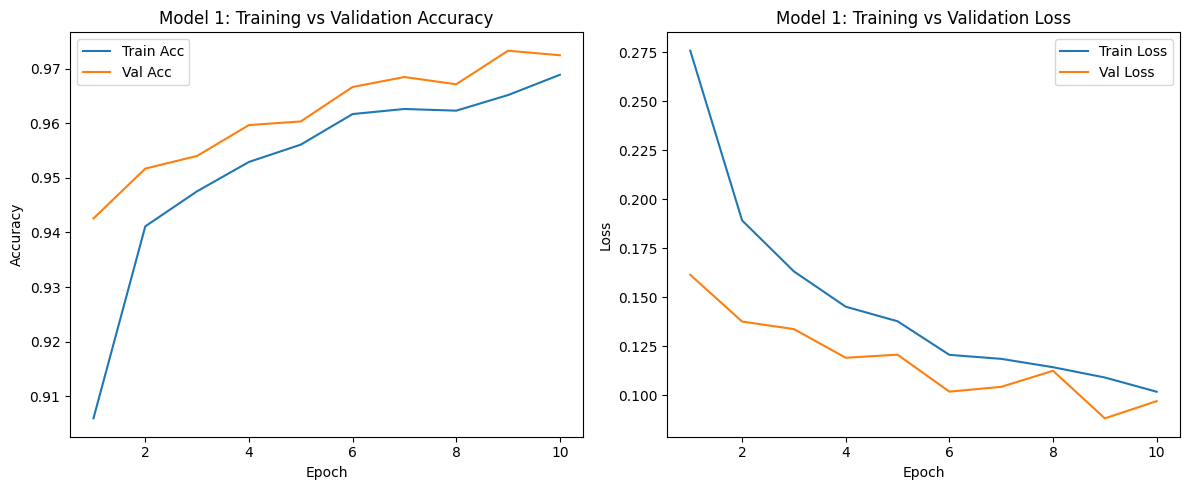

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history["train_acc"]) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_acc"], label="Train Acc")
plt.plot(epochs_range, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model 1: Training vs Validation Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model 1: Training vs Validation Loss")
plt.legend()

plt.tight_layout()
plt.savefig("model1_baseline_curves.png", dpi=150)
plt.show()

In [ ]:
torch.save(model.state_dict(), "model1_baseline_cnn.pth")
print("Model 1 saved as model1_baseline_cnn.pth")

Model 1 saved as model1_baseline_cnn.pth


#step 11: hyperparameter tuning

In [ ]:
learning_rates = [0.01, 0.001, 0.0001]
tuning_results = {}

for lr in learning_rates:
    print(f"\nTraining with learning rate: {lr}")
    model_tune = BaselineCNN(num_classes=3).to(device)
    optimizer_tune = optim.Adam(model_tune.parameters(), lr=lr)
    hist = train_model(model_tune, train_loader, val_loader, criterion, optimizer_tune, epochs=3)
    tuning_results[lr] = hist["val_acc"][-1]

print("\nTuning results (val accuracy after 3 epochs):")
for lr, acc in tuning_results.items():
    print(f"LR={lr}: Val Acc={acc:.4f}")


Training with learning rate: 0.01
Epoch 1/3 | Train Loss: 0.5599 Acc: 0.8221 | Val Loss: 0.2362 Acc: 0.9072 | Time: 481.9s
Epoch 2/3 | Train Loss: 0.2905 Acc: 0.9024 | Val Loss: 0.2726 Acc: 0.8944 | Time: 481.6s
Epoch 3/3 | Train Loss: 0.2805 Acc: 0.9054 | Val Loss: 0.2592 Acc: 0.9125 | Time: 486.2s

Training with learning rate: 0.001
Epoch 1/3 | Train Loss: 0.2829 Acc: 0.9021 | Val Loss: 0.2223 Acc: 0.9283 | Time: 480.7s
Epoch 2/3 | Train Loss: 0.1871 Acc: 0.9403 | Val Loss: 0.1506 Acc: 0.9474 | Time: 479.4s
Epoch 3/3 | Train Loss: 0.1587 Acc: 0.9502 | Val Loss: 0.1367 Acc: 0.9568 | Time: 480.6s

Training with learning rate: 0.0001
Epoch 1/3 | Train Loss: 0.3077 Acc: 0.8895 | Val Loss: 0.2199 Acc: 0.9175 | Time: 491.2s
Epoch 2/3 | Train Loss: 0.2264 Acc: 0.9219 | Val Loss: 0.2036 Acc: 0.9240 | Time: 487.2s
Epoch 3/3 | Train Loss: 0.2015 Acc: 0.9319 | Val Loss: 0.1687 Acc: 0.9394 | Time: 486.3s

Tuning results (val accuracy after 3 epochs):
LR=0.01: Val Acc=0.9125
LR=0.001: Val Acc=0.

# plot the LR comparison

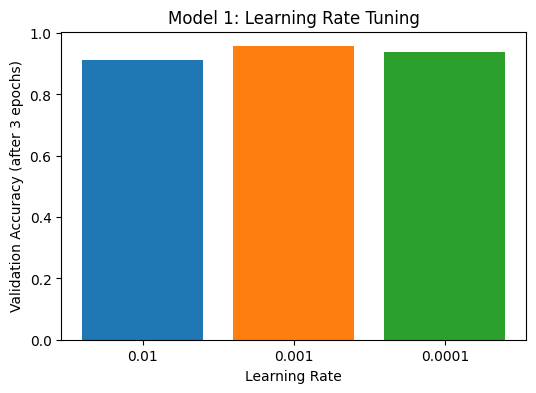

In [ ]:
plt.figure(figsize=(6, 4))
for lr, acc in tuning_results.items():
    plt.bar(str(lr), acc)
plt.xlabel("Learning Rate")
plt.ylabel("Validation Accuracy (after 3 epochs)")
plt.title("Model 1: Learning Rate Tuning")
plt.savefig("model1_lr_tuning.png", dpi=150)
plt.show()